# Rakamin X ID/X Partners Data Scientist Project Based Internship Program

## Task 3: Exploratory Data Analysis

### Library Import

Below are the libraries that will be used in this notebook:

In [3]:
from pymongo import MongoClient
from wordcloud import WordCloud
from scipy import stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn import linear_model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone,BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, cohen_kappa_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore') 

#### Library Reference

##### Database
| Library | Purpose |
|---|---|
| `pymongo · MongoClient` | Connects to MongoDB to fetch and store loan data |

##### Data Manipulation
| Library | Purpose |
|---|---|
| `pandas` | Core library for DataFrames — loading, cleaning, transforming tabular data |
| `numpy` | Numerical operations, array handling, and math functions used throughout |
| `scipy · stats` | Statistical tests — Pearson correlation for numerical feature significance |
| `scipy · chi2_contingency` | Chi-squared test for categorical feature significance against target |

##### Visualization
| Library | Purpose |
|---|---|
| `matplotlib.pyplot` | Base plotting library — figures, axes, and chart rendering |
| `seaborn` | Statistical plots built on matplotlib — histograms, heatmaps, scatterplots |
| `wordcloud · WordCloud` | Generates word cloud from `emp_title` text data |

##### Preprocessing
| Library | Purpose |
|---|---|
| `StandardScaler, MinMaxScaler` | Scales numerical features — StandardScaler for low-outlier cols, MinMaxScaler for high-outlier cols |
| `OneHotEncoder` | Encodes nominal categorical features (`home_ownership`, `initial_list_status`) |
| `OrdinalEncoder` | Encodes ordered categorical features (`grade`, `emp_status`, `verification_status`) with custom category order |
| `ColumnTransformer` | Applies different transformers to different column groups in one step |
| `Pipeline` | Chains preprocessing steps into a single sklearn-compatible object |

##### Imbalanced Data
| Library | Purpose |
|---|---|
| `imblearn · SMOTE` | Oversamples minority classes synthetically to handle class imbalance in `loan_status` |
| `imblearn · Pipeline (ImbPipeline)` | Pipeline variant that supports SMOTE as an intermediate step during fitting |

##### Models
| Library | Purpose |
|---|---|
| `LogisticRegression` | Baseline linear classifier for multiclass loan status prediction |
| `RandomForestClassifier` | Ensemble tree model — main model chosen for tuning and deployment |
| `DecisionTreeClassifier` | Single decision tree — imported as base reference |
| `XGBClassifier` | Gradient boosting classifier — imported for potential experimentation |
| `SVC` | Support vector classifier — imported for potential experimentation |

##### Model Selection & Evaluation
| Library | Purpose |
|---|---|
| `train_test_split` | Splits data into training and test sets (75/25) |
| `GridSearchCV` | Exhaustive hyperparameter search with cross-validation for RandomForest tuning |
| `classification_report` | Prints per-class precision, recall, and F1 for all `loan_status` classes |
| `confusion_matrix · ConfusionMatrixDisplay` | Shows prediction vs actual counts — used to extract false negatives |
| `mean_absolute_error` | Measures average ordinal distance between predicted and actual classes |
| `cohen_kappa_score` | Quadratic-weighted kappa — primary metric that respects ordinal class order |

##### Utilities
| Library | Purpose |
|---|---|
| `joblib` | Saves and loads the trained model as a `.pkl` file for deployment |
| `clone, BaseEstimator, TransformerMixin` | `clone` prevents shared preprocessor state; base classes enable custom `DataFrameConverter` |
| `warnings` | Suppresses non-critical sklearn/pandas warnings during notebook runs |

### Data Extraction

In [4]:
client = MongoClient("mongodb://localhost:27017/")
collection = client["lendingclub_db"]["loans_clean"]
df = pd.DataFrame(list(collection.find()))

# Drop the MongoDB internal _id column
df = df.drop(columns=["_id"])
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,12000,12000,12000.0,36,13.53,407.40,B,B5,On road manager,10,...,0.0,119.17,0.0,53.0,1,INDIVIDUAL,0.0,15386.0,13605.0,8100.0
1,3000,3000,3000.0,36,12.85,100.87,B,B4,Auditor,10,...,0.0,2677.23,0.0,69.0,1,INDIVIDUAL,0.0,154.0,19530.0,5300.0
2,7200,7200,7200.0,36,10.99,235.69,B,B2,executive administrator,4,...,0.0,4539.95,0.0,59.0,1,INDIVIDUAL,0.0,0.0,45598.0,9800.0
3,9000,9000,9000.0,36,14.98,311.90,C,C3,Category Manager,10,...,0.0,5114.64,0.0,70.0,1,INDIVIDUAL,0.0,4009.0,80436.0,37200.0
4,16000,16000,16000.0,60,19.22,416.99,D,D4,District Sales Manager,8,...,0.0,416.99,0.0,60.0,1,INDIVIDUAL,0.0,0.0,188654.0,22600.0


The data is extracted from a clean source

### Data Analysis

#### 1. Target variable value distribution

In [5]:
df['loan_status'].value_counts()

loan_status
Fully Paid            5178
Charged Off           1138
Late (31-120 days)     313
In Grace Period        137
Late (16-30 days)       70
Default                 38
Name: count, dtype: int64

It seems the value of our target is biased towards the 'fully paid' one. Because of this, we will perform SMOTE in the Feature Engineering part.

Let's visualize the differences in value counts:

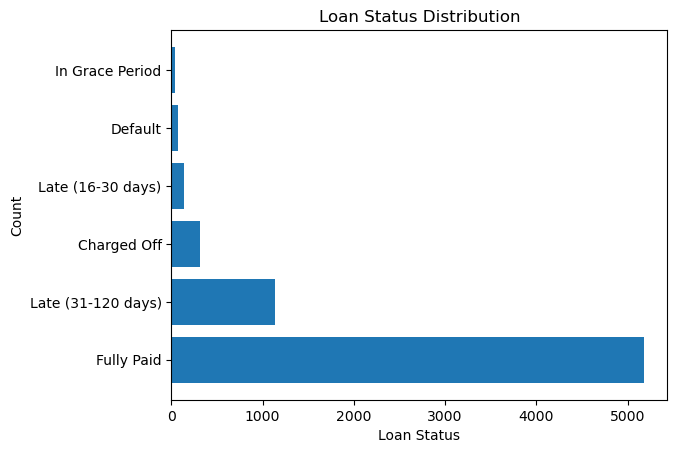

In [6]:
plt.barh(df['loan_status'].unique(), df['loan_status'].value_counts())
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

#### 2. Numerical Value Distribution

We will check it again later in the Feature Engineering task, but this will be useful for visualization purposes

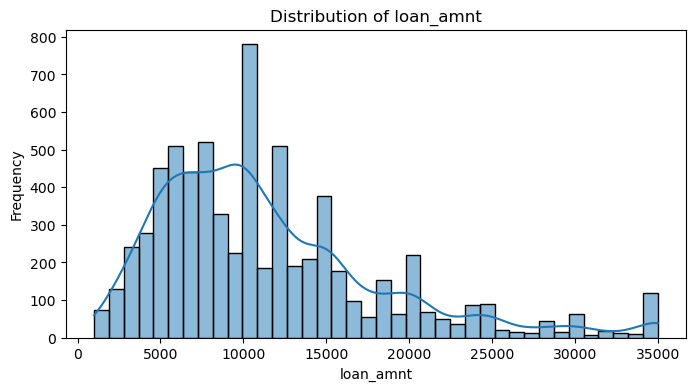

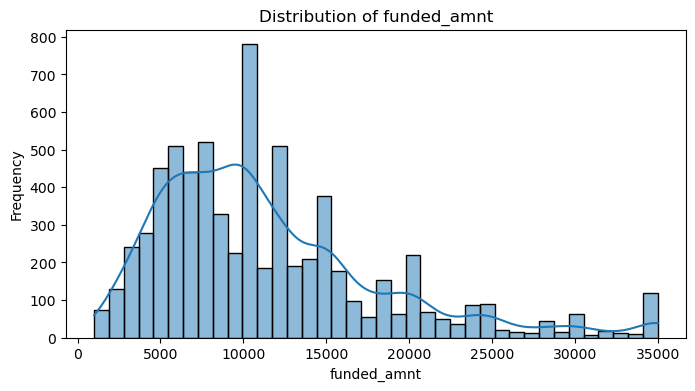

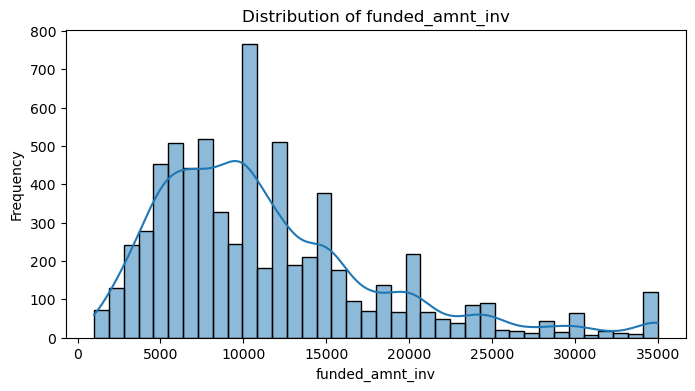

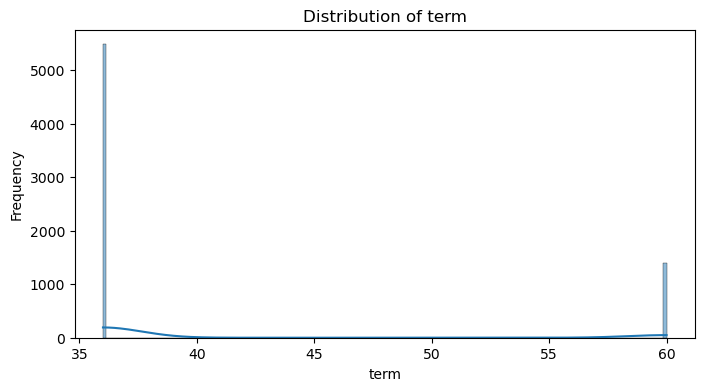

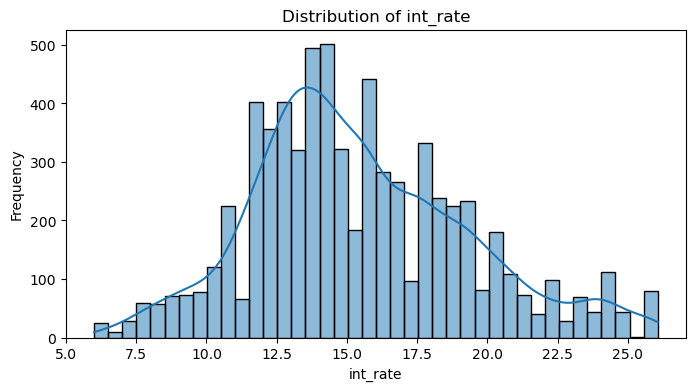

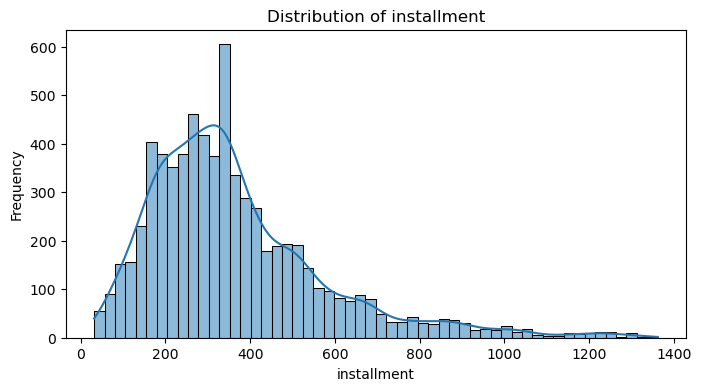

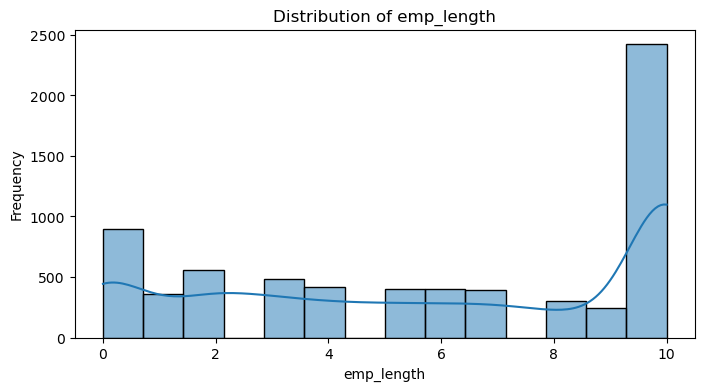

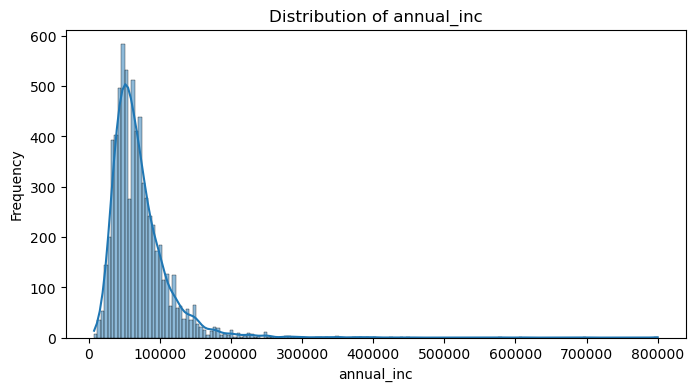

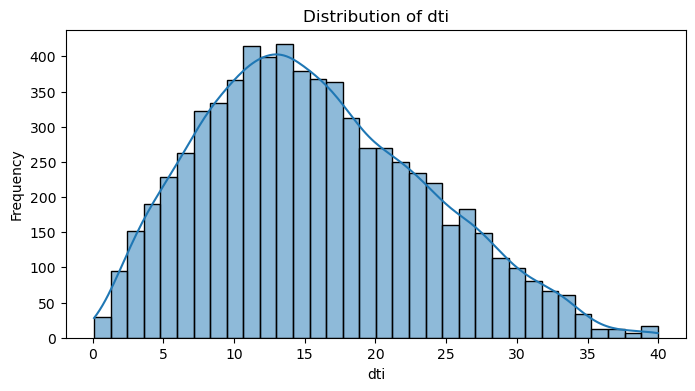

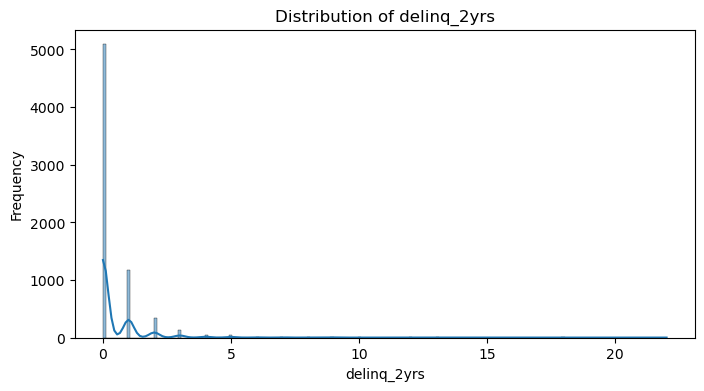

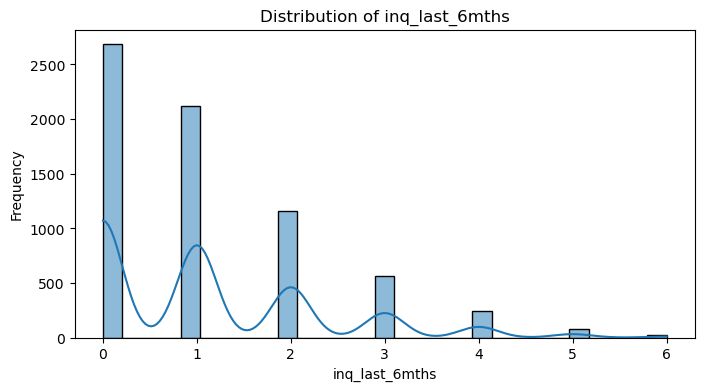

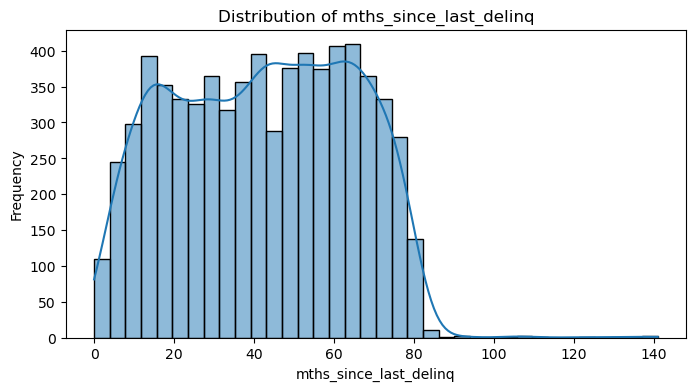

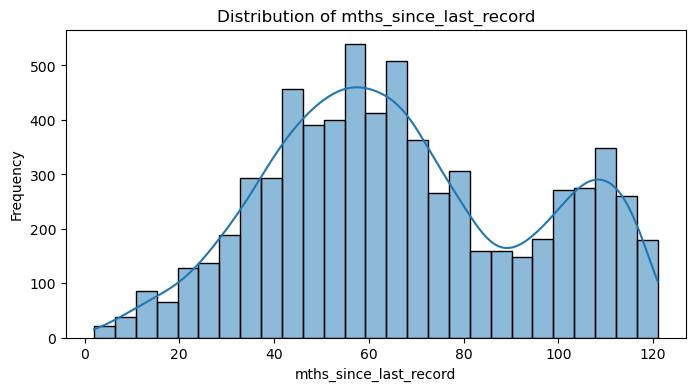

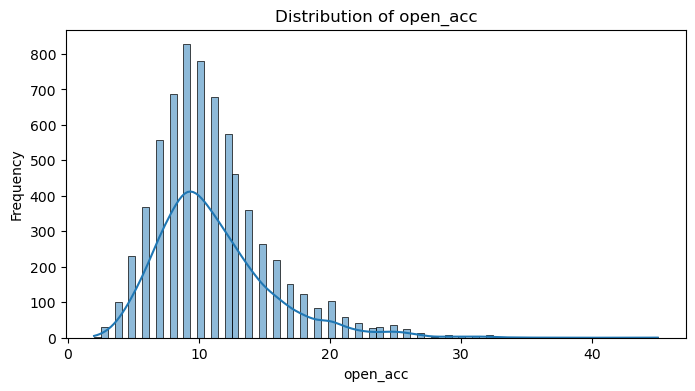

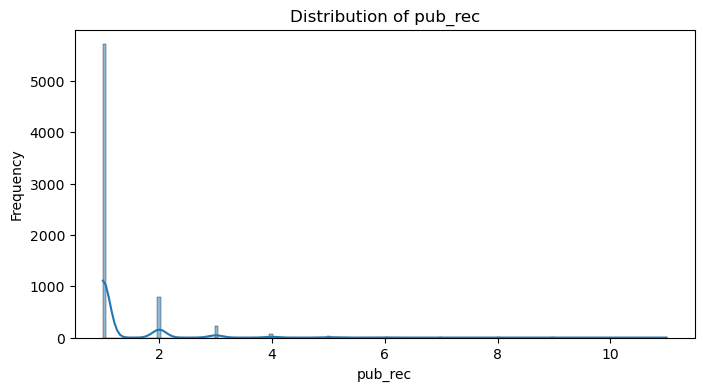

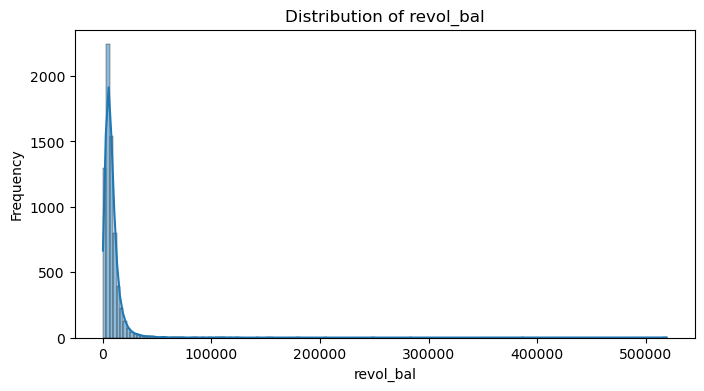

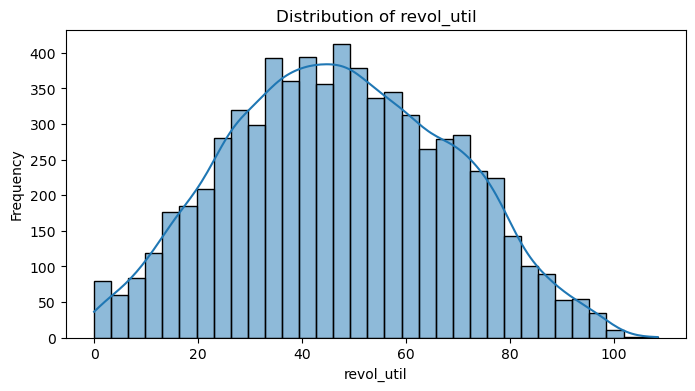

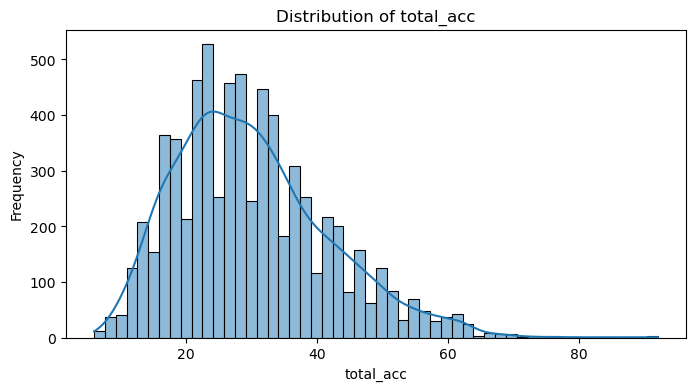

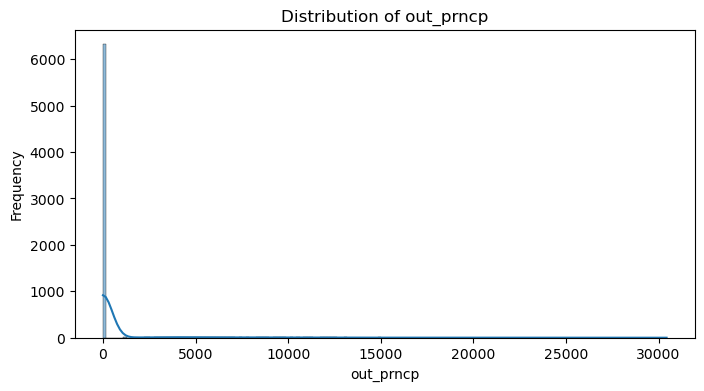

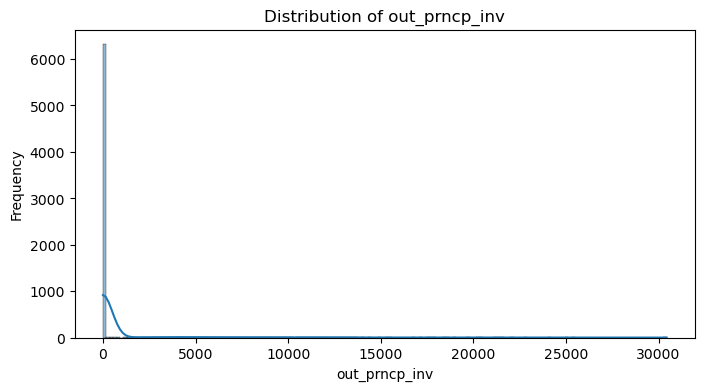

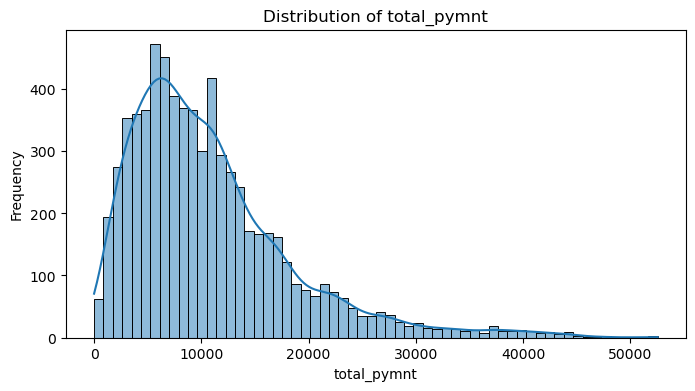

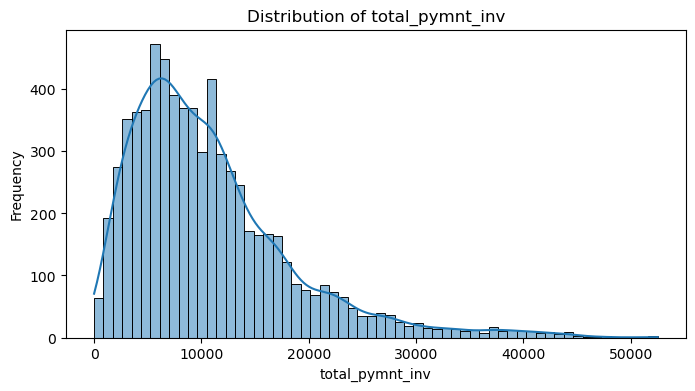

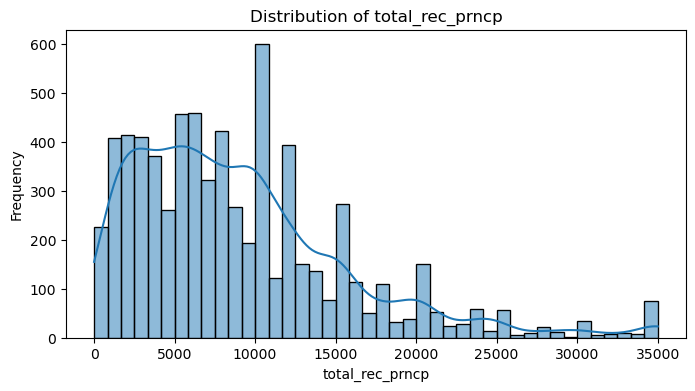

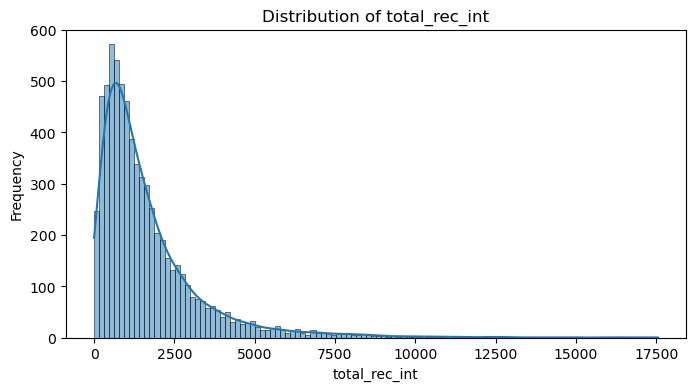

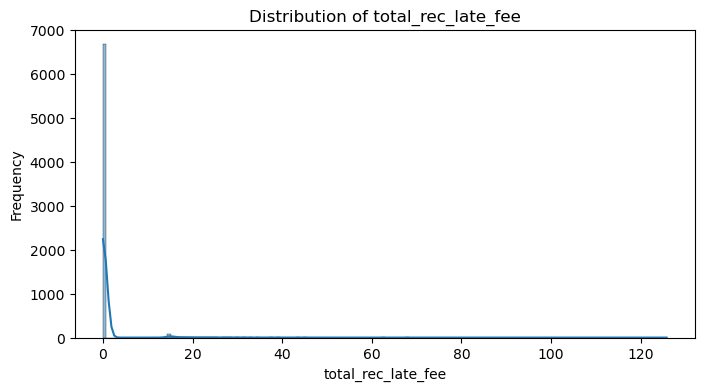

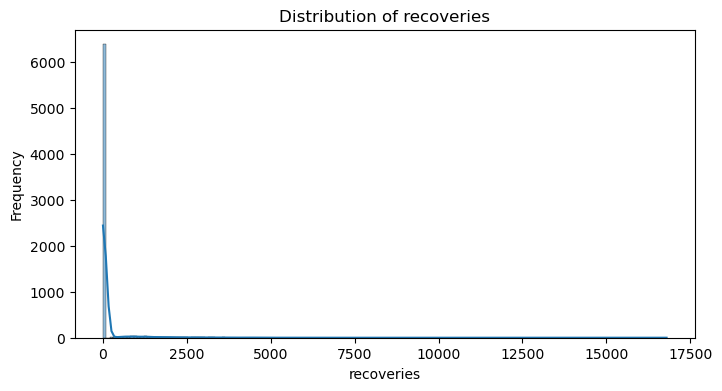

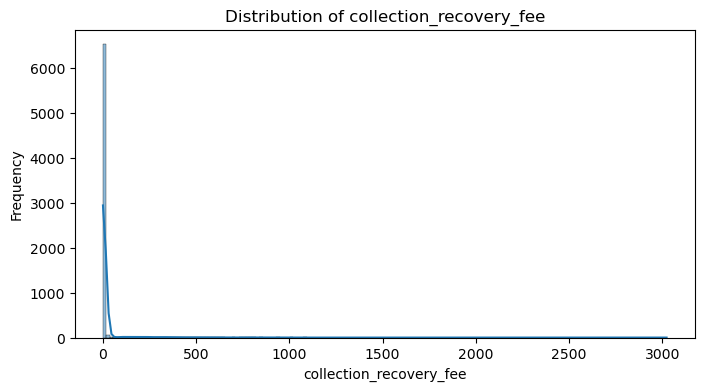

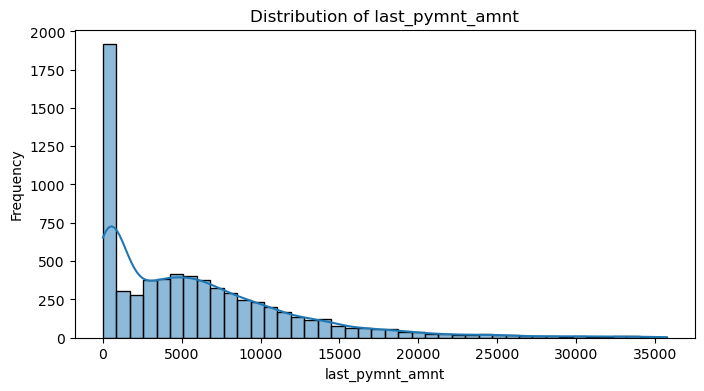

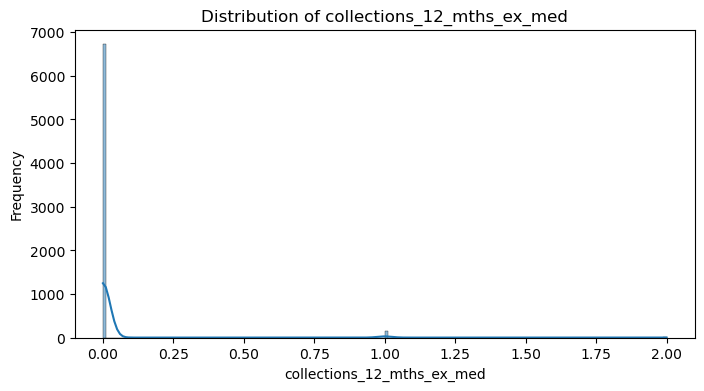

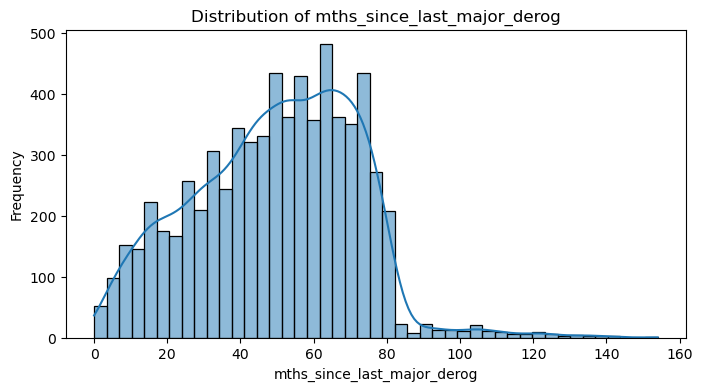

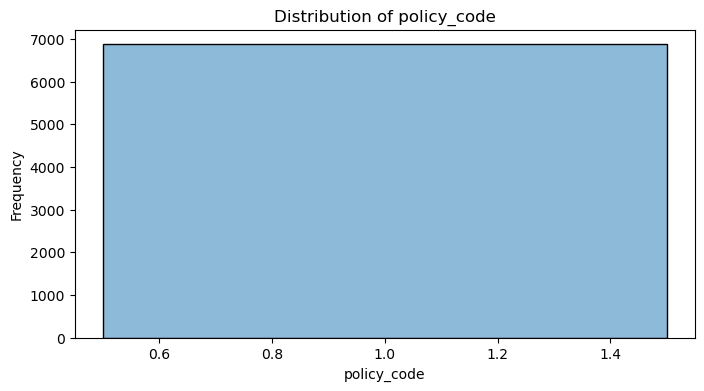

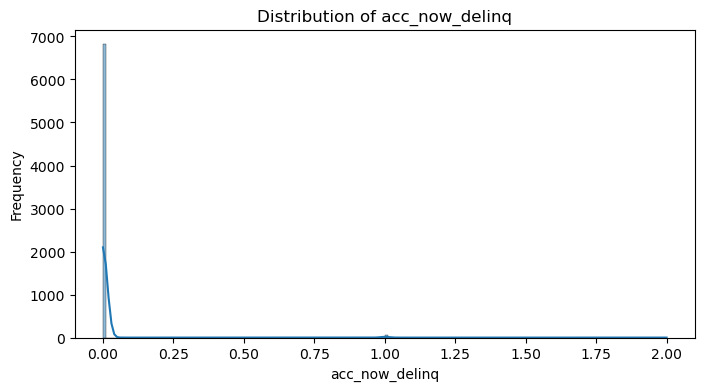

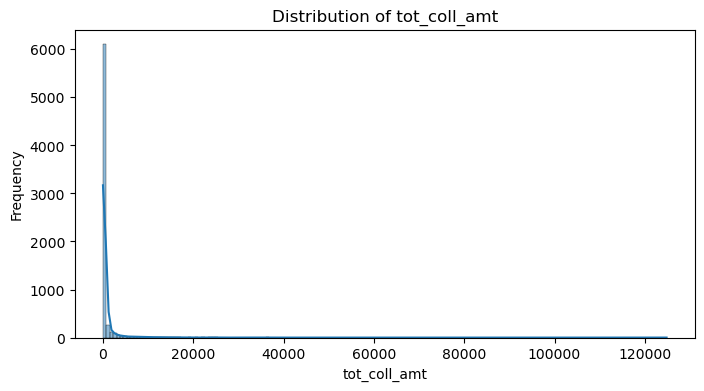

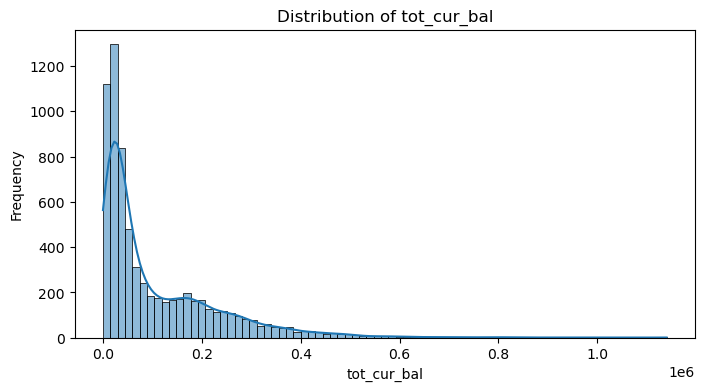

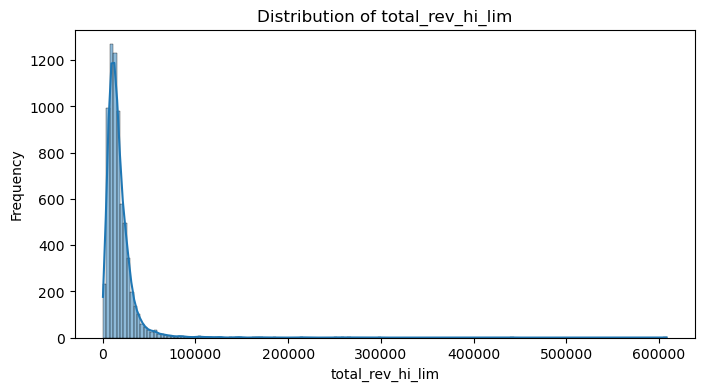

In [7]:
for col in df.columns:
    if df[col].dtype != 'object' and df[col].dtype != 'datetime64[ns]':
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

The numerical variables in this data has a tendency to be skewed to the left. This means most of the value  of each variables are less than the median.

#### 3. Numerical Value Correlation

In order to avoid autocorrelation among numerical values, this is a necessary part of the visualization.

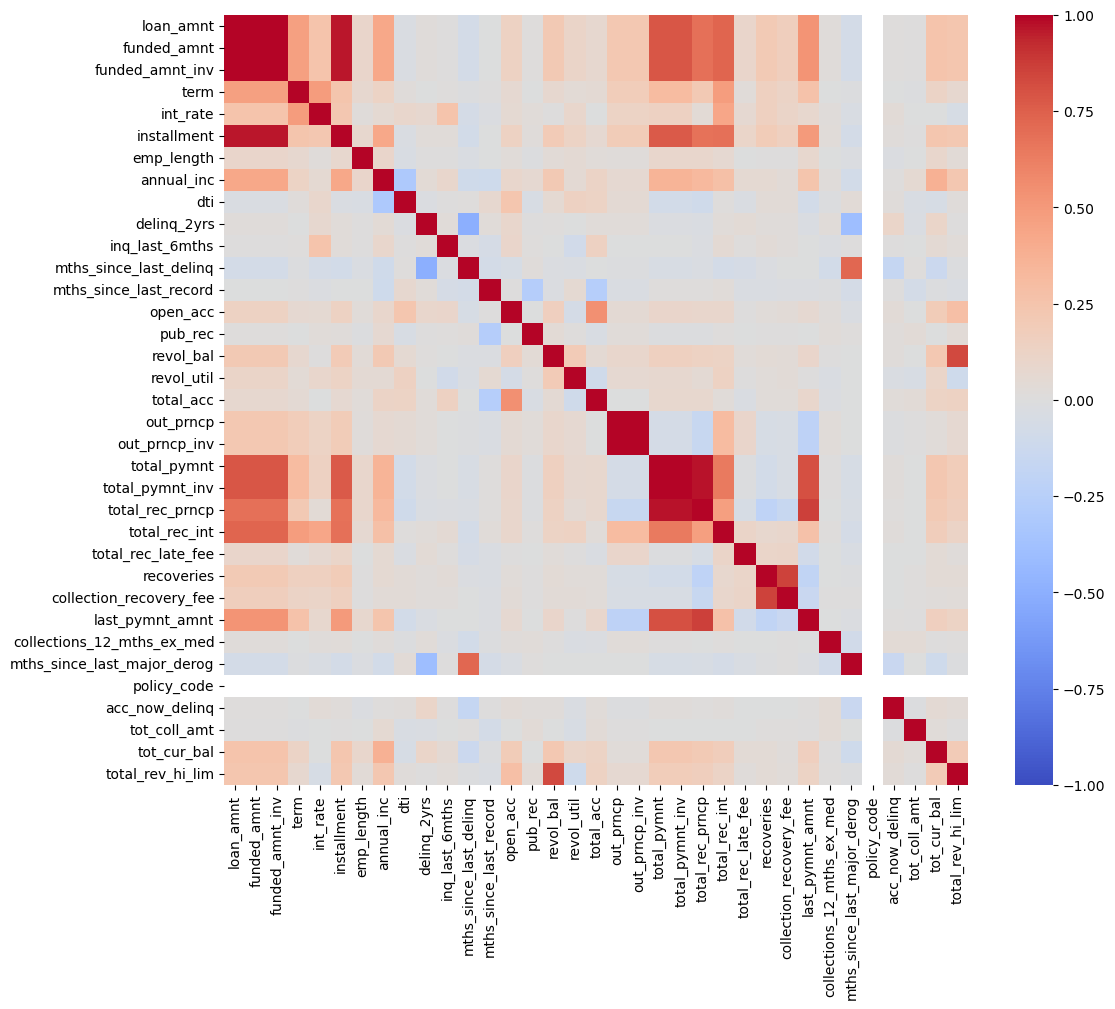

In [8]:
data = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,10))
sns.heatmap(data, vmin=-1, vmax=1, cmap='coolwarm', annot=False, fmt='.2f')
plt.show()

There seems to be correlations between loan amount, funded amount, funded amount inv, and installment. Based on the Data Dictionary, there seems to also be correlation between these data which is why we must visualize the distribution among them to decide which to remove:

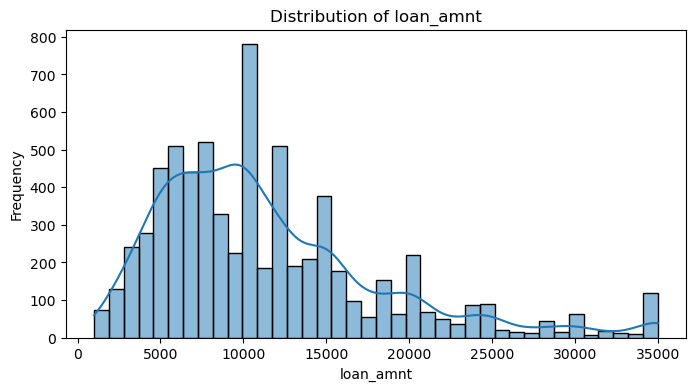

Skewness of loan_amnt: 1.30


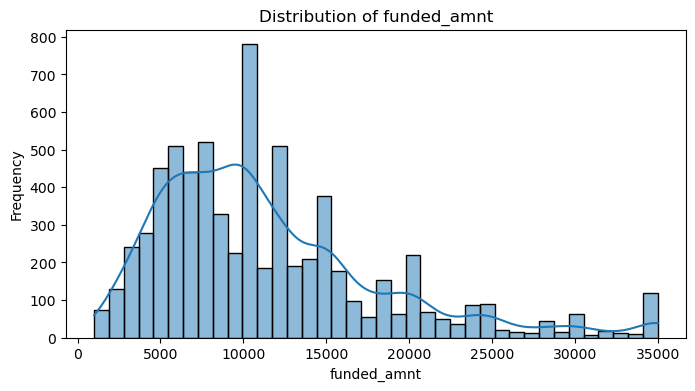

Skewness of funded_amnt: 1.30


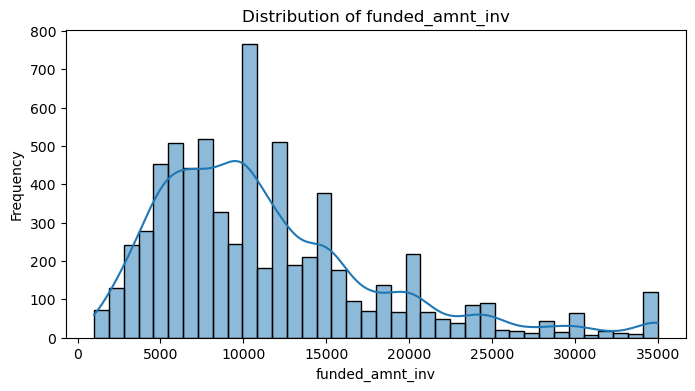

Skewness of funded_amnt_inv: 1.30


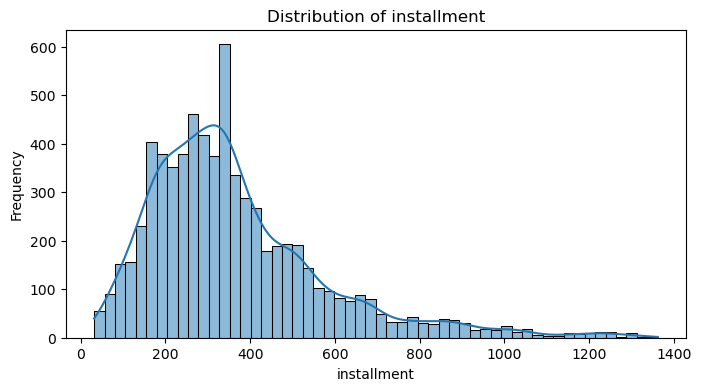

Skewness of installment: 1.47


In [9]:
considered_to_be_removed=['loan_amnt','funded_amnt','funded_amnt_inv','installment']
for col in considered_to_be_removed:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    print(f"Skewness of {col}: {df[col].skew():.2f}")

Installment is the one that is considered to be removed first, and the selected one among the rest three will be decided by the correlation with the target variable (loan status)

#### 4. Loan Status for Each Grade

In this part of the analysis, each grade will be shown the percentage of loan status they have

In [10]:
df['loan_status'].unique()

array(['Fully Paid', 'Late (31-120 days)', 'Charged Off',
       'Late (16-30 days)', 'Default', 'In Grace Period'], dtype=object)

In [11]:
grade_list = [i for i in df['grade'].unique()]
print(grade_list)

['B', 'C', 'D', 'A', 'F', 'E', 'G']


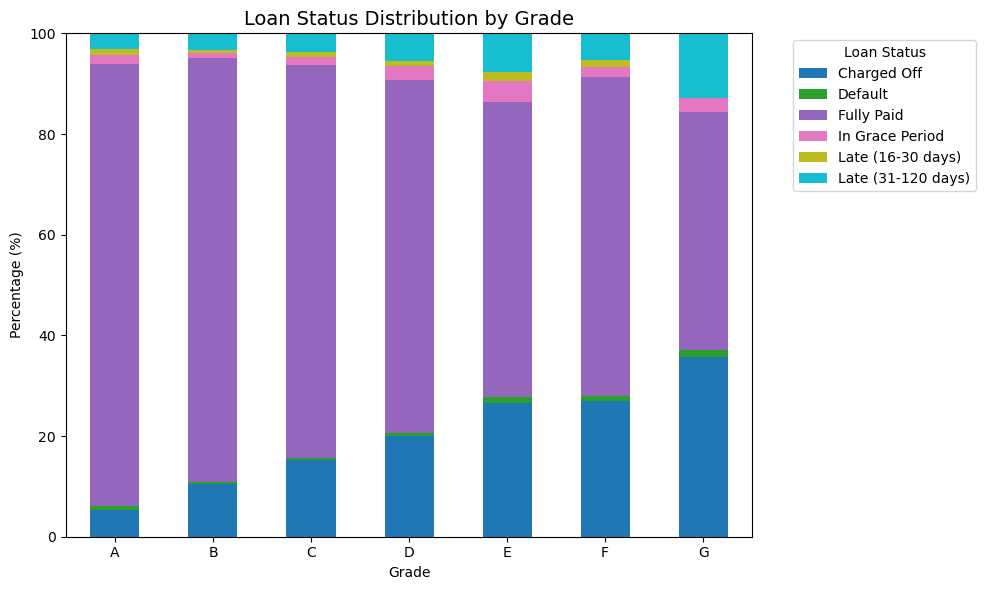

In [12]:
# Calculate percentage of each loan_status per grade
grade_status = (
    df.groupby(['grade', 'loan_status'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages
grade_status_pct = grade_status.div(grade_status.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = grade_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab10',
    edgecolor='none'
)

# Formatting
plt.title('Loan Status Distribution by Grade', fontsize=14)
plt.xlabel('Grade')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Based on the visualization, we can conclude that the data is accurate since the lower the grade goes, the less chances that the loan is paid off, and the higher chances of defaulting or charged off. Althoug, it's strange that grade F has a higher chance of fully pay their loan compared to grade E.

#### 5. Job Titles data

From the clean data, we want to see the variety of job title it has

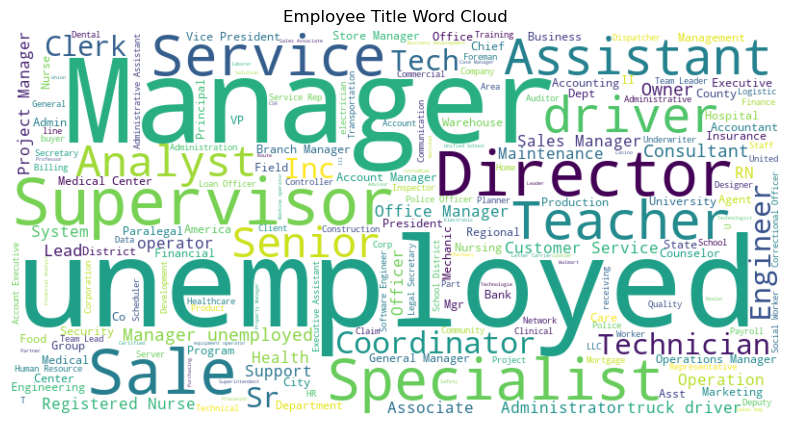

In [13]:
text = ' '.join(df['emp_title'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(11, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Employee Title Word Cloud')
plt.show()

From the size of the text, it seems unemployed people makes the most of the data followed by Manager and Supervisor. Because of the cardinality, we may create another column that inform the person's employment status instead of job titles

#### 6. Loan Status based on employment status

In this part, we want to take a look at the loan status based on the employment status of the person's to test our previous assumption

First, let's take a look at the unemployed people:

In [14]:
df[df['emp_title']=='unemployed']['loan_status'].value_counts()

loan_status
Fully Paid            387
Charged Off           119
Late (31-120 days)     25
In Grace Period         6
Late (16-30 days)       4
Default                 1
Name: count, dtype: int64

Then, let's take a look at the ones who are employed:

In [15]:
df[df['emp_title']!='unemployed']['loan_status'].value_counts()

loan_status
Fully Paid            4791
Charged Off           1019
Late (31-120 days)     288
In Grace Period        131
Late (16-30 days)       66
Default                 37
Name: count, dtype: int64

Because of the differences in total number, we need to visualize this using percentage instead:

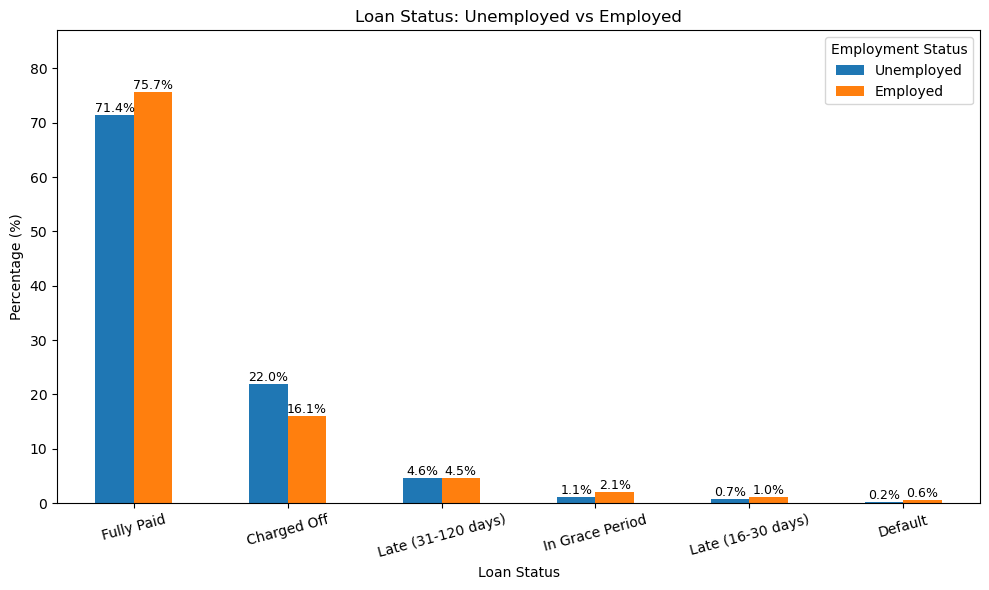

In [16]:
# Calculate percentages for each group
unemployed = (
    df[df['emp_title'] == 'unemployed']['loan_status']
    .value_counts(normalize=True) * 100
)

employed = (
    df[df['emp_title'] != 'unemployed']['loan_status']
    .value_counts(normalize=True) * 100
)

# Combine into a single DataFrame
compare_df = pd.DataFrame({
    'Unemployed': unemployed,
    'Employed': employed
}).fillna(0)

# Plot
ax = compare_df.plot(kind='bar', figsize=(10, 6), edgecolor='none')

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9
    )

plt.title('Loan Status: Unemployed vs Employed')
plt.xlabel('Loan Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.ylim(0, compare_df.values.max() * 1.15)
plt.legend(title='Employment Status')
plt.tight_layout()
plt.show()

Based on the visualization, employed people have a higher chance of fully paying their loan but also higher chance to default their debt (although only by 0.4%).

#### 7. Employment length correlation with loan amount

Another interesting variable in the data is the employment length, we want to see if the length itself correlates with the loan amount they borrowed.

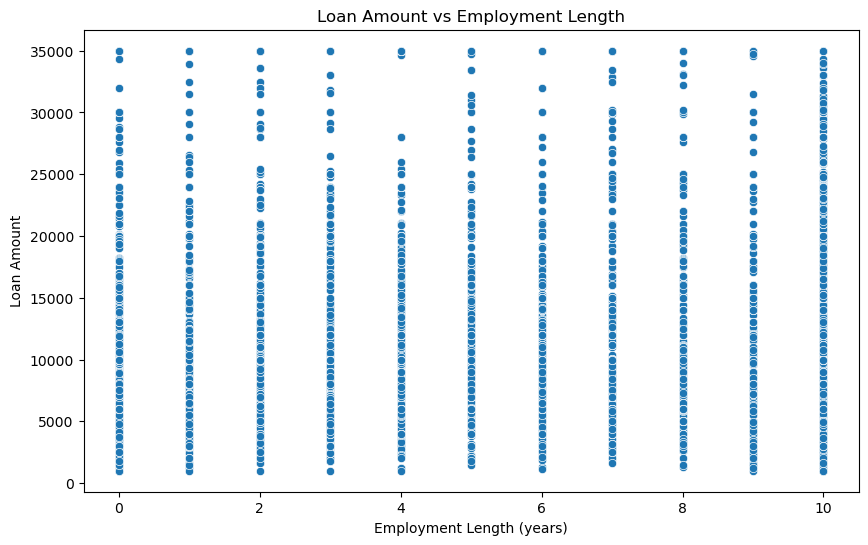

In [17]:
emp_length=df['emp_length']
borrowed=df['loan_amnt']
data = pd.DataFrame({'emp_length': emp_length, 'loan_amnt': borrowed})
plt.figure(figsize=(10, 6))
sns.scatterplot(x='emp_length', y='loan_amnt', data=data)
plt.title('Loan Amount vs Employment Length')
plt.xlabel('Employment Length (years)')
plt.ylabel('Loan Amount')
plt.show()

Based on the scatterplot, there seems to be no correlation

#### 8. Correlation between target variable with numerical columns

Let's take a look at the numerical variables correlation towards our target variable

In [18]:
target=df['loan_status']

In [19]:
p_values = [] # to store p-values for each feature
result = [] # to store significance result for each feature
correlation = [] # to store correlation coefficients for each feature

for col in df.columns:
    if df[col].dtype != 'object' and df[col].dtype != 'datetime64[ns]':
        corr, p_value = stats.pearsonr(df[col], target.astype('category').cat.codes) # Convert target to numeric codes for correlation
        p_values.append(p_value)
        result.append('Significant' if p_value < 0.05 else 'Not Significant') # Store significance result based on p-value threshold
        correlation.append(corr)

pd.DataFrame({
    'Feature': df.select_dtypes(include=[np.number]).columns,
    'Correlation': correlation,
    'P-Value': p_values,
    'Significance': result
})

,Feature,Correlation,P-Value,Significance
0,loan_amnt,-0.039714,9.897976e-04,Significant
1,funded_amnt,-0.039718,9.887195e-04,Significant
2,funded_amnt_inv,-0.039739,9.825880e-04,Significant
3,term,-0.047032,9.586906e-05,Significant
4,int_rate,-0.080429,2.423291e-11,Significant
5,installment,-0.036417,2.529845e-03,Significant
6,emp_length,0.013853,2.508068e-01,Not Significant
7,annual_inc,0.008014,5.064803e-01,Not Significant
8,dti,-0.045118,1.825799e-04,Significant
9,delinq_2yrs,-0.032474,7.089151e-03,Significant


Now let's select the numerical variables with significant correlation to our target variable:

In [20]:
significant_num = []
for col in df.select_dtypes(include=[np.number]).columns:
    corr, p_value = stats.pearsonr(df[col], target.astype('category').cat.codes)
    if p_value < 0.05:
        significant_num.append(col)

Previously, we want to drop some variable related to borrowed amount. Based on the numbers above, the loan amount is the one to be used because of its correlation with the target variable

In [21]:
significant_num.remove('funded_amnt')
significant_num.remove('funded_amnt_inv')
significant_num.remove('installment')

#### 9. Correlation with categorical columns

Now let's check the categorical ones

In [22]:
p_values = []
result = []
correlation = []

for col in df.columns:
    if df[col].dtype == 'object':
        contingency_table = pd.crosstab(df[col], target)
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        p_values.append(p_value)
        result.append('Significant' if p_value < 0.05 else 'Not Significant')
        correlation.append(chi2)

pd.DataFrame({
    'Feature': df.select_dtypes(include=['object']).columns,
    'Chi-Squared': correlation,
    'P-Value': p_values,
    'Significance': result
})

,Feature,Chi-Squared,P-Value,Significance
0,grade,313.794553,4.999013e-49,Significant
1,sub_grade,499.489476,3.830906e-34,Significant
2,emp_title,21968.813484,9.857160e-01,Not Significant
3,home_ownership,13.579932,1.930285e-01,Not Significant
4,verification_status,41.234625,1.025435e-05,Significant
5,loan_status,34370.000000,0.000000e+00,Significant
6,pymnt_plan,0.000000,1.000000e+00,Not Significant
7,purpose,83.903475,2.251427e-02,Significant
8,title,3029.829667,1.000000e+00,Not Significant
9,zip_code,3539.847527,2.002111e-01,Not Significant


Let's save the ones that are significant (except loan status)

In [23]:
significant_cat = []
for col in df.select_dtypes(include=['object']).columns:
    if col != 'loan_status':
        contingency_table = pd.crosstab(df[col], target)
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        if p_value < 0.05:
            significant_cat.append(col)

For the ones that are significant, let's check the cardinality and perhaps the similarity towards other variable

In [24]:
for col in significant_cat:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

Value counts for grade:
grade
C    2226
B    1864
D    1474
E     744
F     268
A     228
G      70
Name: count, dtype: int64

Value counts for sub_grade:
sub_grade
B4    512
B5    494
C3    480
C1    459
C4    445
C2    430
B3    423
C5    412
D1    370
D2    338
D3    306
D4    257
B2    249
D5    203
E2    187
B1    186
E1    183
E3    156
E4    114
A5    105
E5    104
F2     82
A4     69
F1     65
F3     53
F4     39
F5     29
A3     28
G1     27
A2     19
G2     17
G3     14
G5      8
A1      7
G4      4
Name: count, dtype: int64

Value counts for verification_status:
verification_status
Verified           2779
Source Verified    2745
Not Verified       1350
Name: count, dtype: int64

Value counts for purpose:
purpose
debt_consolidation    4229
credit_card           1150
home_improvement       581
other                  400
major_purchase         131
small_business         101
medical                 87
car                     70
moving                  46
house                   

Because the sub_grade is similar to grade, we need to remove this variable

In [25]:
significant_cat.remove('sub_grade')

#### 10. Check if employment status is correlated or has significance

Employment title may not be significant due to its cardinality, but how about employment status? Let's check if it's significant

In [26]:
df['emp_status'] = df['emp_title'].apply(lambda x: 'unemployed' if x == 'unemployed' else 'employed')

In [27]:
p_values = []
result = []
correlation = []

contingency_table = pd.crosstab(df['emp_status'], target)
chi2, p_value, _, _ = chi2_contingency(contingency_table)
p_values.append(p_value)
result.append(( 'emp_status', p_value))
correlation.append(chi2)
pd.DataFrame({
    'Feature': ['emp_status'],
    'Chi-Squared': correlation,
    'P-Value': p_values,
    'Significance': ['Significant' if p_value < 0.05 else 'Not Significant']
})

,Feature,Chi-Squared,P-Value,Significance
0,emp_status,15.789486,0.007472,Significant


Because of its significance, we need to add it to our significant categorical variables

In [28]:
significant_cat.append('emp_status')

## Task 4: Feature Engineering

### Seperating variables & Test data

#### 1. Seperating X and y variable

They y variable consist of loan_status data, while the X consist of the significant variable we have saved in the previous EDA part

In [29]:
y=df['loan_status']
X=df.drop(columns=['loan_status'])[significant_cat + significant_num]
y.replace({'Fully Paid': 0, 'In Grace Period': 1, 'Late (16-30 days)': 2, 'Late (31-120 days)': 3, 'Default': 4, 'Charged Off': 5}, inplace=True)

In [30]:
y.value_counts()

loan_status
0    5178
5    1138
3     313
1     137
2      70
4      38
Name: count, dtype: int64

#### 2. Seperating testing and training data

To avoid overfitting, the ratio will be 75:25

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

### Outlier Handling

#### 1. Skewness distribution check

Before handling any outlier, we must check the skewness of our data first

In [32]:
num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

listItem= [] # to store column name, skewness value, and distribution type for each numerical column

for col in num_cols:
  listItem.append([col, round(X_train[col].skew(),1), np.where(
    (round(X_train[col].skew(),1) <= 0.5) & (round(X_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['Column', 'Skewness', 'Distribution'], data= listItem)
skewness

,Column,Skewness,Distribution
0,loan_amnt,1.3,skewed
1,term,1.5,skewed
2,int_rate,0.5,normal
3,dti,0.4,normal
4,delinq_2yrs,6.2,skewed
5,mths_since_last_delinq,-0.0,normal
6,out_prncp,5.2,skewed
7,out_prncp_inv,5.2,skewed
8,total_pymnt,1.5,skewed
9,total_pymnt_inv,1.5,skewed


#### 2. Outlier counter check

Now we check the percentages of them in our data

In [33]:
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['Column'][row]
  #checking upper and lower boundary
  if skewness['Distribution'][row] == 'skewed': # if the distribution is skewed, use IQR method to calculate the boundaries
    IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
    lower_boundary = X_train[col].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[col].quantile(0.75) + (IQR * 3)
  else: # if the distribution is normal, use z-score method to calculate the boundaries
    lower_boundary = X_train[col].mean() - 3* X_train[col].std()
    upper_boundary = X_train[col].mean() + 3* X_train[col].std()
  #append to list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[col] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[col] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    #round the value
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,loan_amnt,40500.00,-19000.00,0.00
1,term,36.00,36.00,20.41
2,int_rate,26.95,3.95,0.00
3,dti,39.11,-7.75,0.16
4,delinq_2yrs,4.00,-3.00,1.49
5,mths_since_last_delinq,108.23,-24.10,0.08
6,out_prncp,0.00,0.00,8.15
7,out_prncp_inv,0.00,0.00,8.15
8,total_pymnt,39292.97,-19765.20,0.80
9,total_pymnt_inv,39293.62,-19771.36,0.80


For the outliers that have percentage less than 1, we scale it normally. But the ones with percentage more than 1 will be used in minmax scaler.

### Scaling & Encoding

#### 1. Numerical scaling

As mentioned before, the variables with outliers percentage more than 1 will be scaled based using minimum and maximum methode while the one with less than one will be scaled in a standard way.

In [34]:
num_features_scaler= []
num_features_minmax = []
for col in outliers['column']:
  if -1<=outliers[outliers['column'] == col]['percentage_total_outlier'].values[0] <=1:
    num_features_scaler.append(col)
  else:
    num_features_minmax.append(col)

#### 2. Categorical encoding

In order to decide the encoding method for categorical variable (ordinal vs one-hot), the values of each variables need to be shown first

In [35]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"Column: {col}")
        print(X[col].value_counts())
        print("\n")

Column: grade
grade
C    2226
B    1864
D    1474
E     744
F     268
A     228
G      70
Name: count, dtype: int64


Column: verification_status
verification_status
Verified           2779
Source Verified    2745
Not Verified       1350
Name: count, dtype: int64


Column: purpose
purpose
debt_consolidation    4229
credit_card           1150
home_improvement       581
other                  400
major_purchase         131
small_business         101
medical                 87
car                     70
moving                  46
house                   38
vacation                32
wedding                  6
renewable_energy         3
Name: count, dtype: int64


Column: emp_status
emp_status
employed      6332
unemployed     542
Name: count, dtype: int64




In [36]:
print(significant_cat)

['grade', 'verification_status', 'purpose', 'emp_status']


Now time to decide the encoding method:

In [37]:
ordinal_features = ['grade','verification_status']
onehot_features = ['purpose','emp_status']

Grade and verification status will be using ordinal, while purpose and employment status will be using one-hot methode. The reason employment status is encoded this way is because if a variable only holds two values, the ordinal order will only be 1st and 2nd which may not be useful for model training.

Now is the time to structure the hierarchy of the ordinal values:

In [38]:
grade_ordinal = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_ord = OrdinalEncoder(categories=[grade_ordinal], dtype=int)
verification_status_ordinal = ['Not Verified', 'Source Verified', 'Verified']
verification_status_ord = OrdinalEncoder(categories=[verification_status_ordinal], dtype=int)

### Pipeline

In [39]:
numerical_transformer_scaler = Pipeline(steps=[
    ('scaler', StandardScaler())
])
numerical_transformer_minmax = Pipeline(steps=[
    ('minmax', MinMaxScaler())
])
categorical_transformer_onehot = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
categorical_transformer_ordinal = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

In [40]:
preprocessor = ColumnTransformer(transformers=[ 
    ('num_scaler', numerical_transformer_scaler, num_features_scaler),
    ('num_minmax', numerical_transformer_minmax, num_features_minmax),
    ('cat_onehot', categorical_transformer_onehot, onehot_features),
    # Each ordinal feature gets its own encoder with the correct category order
    ('cat_grade', Pipeline(steps=[('ordinal', grade_ord)]), ['grade']),
    ('cat_verification', Pipeline(steps=[('ordinal', verification_status_ord)]), ['verification_status']),
])

smote = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=42)


This is the preprocessor that will be used in the pipeline. It applies the appropriate transformations to each group of features based on their characteristics that are explained above.

The smote below will be used to balance the number of values in our target variable

In [41]:
class DataFrameConverter(BaseEstimator, TransformerMixin): 
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]  
        return self

    def transform(self, X, y=None):
        return pd.DataFrame(X) 

> This custom transformer converts the output of the preprocessor back to a DataFrame with appropriate column names for use in the pipeline

## Task 5: Modelling

### Model Pipeline

Below are the pipeline created for the model that we want to experiment on:

In [42]:
pipe_logreg = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  
    ('classifier', linear_model.LogisticRegression(random_state=42))
])

pipe_rf = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_dt = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  
    ('classifier', DecisionTreeClassifier(random_state=42))
])

pipe_xgb = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

pipe_svc = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  
    ('classifier', SVC(random_state=42, probability=True, decision_function_shape='ovr'))
])

The pipes for the model follows similar 3 steps, but the 4th one depends on the model we want to experiment on

### Model Testing
In this part of the task, we will test every model and store the score for later review

#### 1. Logistic Regression

Let's try predicting the test data with logistic regression. Logistic regression uses Logs formula in a probability to predict the next upcoming data with the existing variable

In [43]:
pipe_logreg.fit(X_train, y_train)
y_pred_logreg = pipe_logreg.predict(X_test)

let's view the classification report so that we can see how the model predicts the target values

In [44]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.19      0.25      0.22        28
           2       0.21      0.29      0.25        24
           3       0.46      0.21      0.29        76
           4       0.14      0.50      0.21        10
           5       1.00      0.99      0.99       289

    accuracy                           0.93      1719
   macro avg       0.50      0.54      0.49      1719
weighted avg       0.94      0.93      0.94      1719



The model is able to predict the value of 0 and 5, but still insufficient for value 1-4.

Now let's see the MAE and Cohen's Kappa metric:

In [45]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_logreg)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_logreg, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0971
Cohen's Kappa (quadratic): 0.9758


Mean Absolute Error (MAE) measures the average distance between predicted and actual ordinal classes. From the score we can infer that the model had < 0.1 class levels away from the correct answer. In practical terms, when it's wrong it's almost always predicting an adjacent class (e.g. predicting In Grace Period (1) instead of Fully Paid (0)), not wildly off like predicting Charged Off (5) for a Fully Paid (0) loan.

Cohen's Kappa measures the agreement between predicted value with the actual value. A score of 0.97 is close to 1 which indicates almost perfect agreement.

Now let's view the confusion matrix to visualize the false prediction

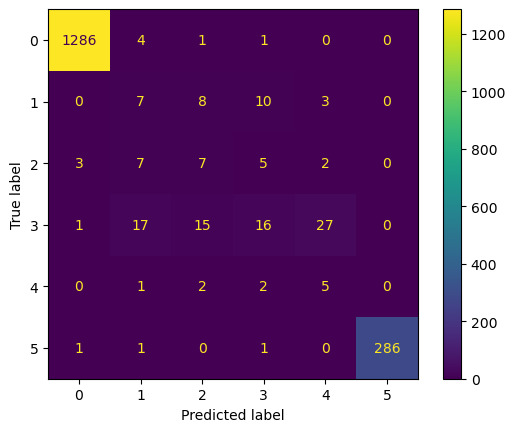

In [46]:
cm_test= confusion_matrix(y_test, y_pred_logreg)
ConfusionMatrixDisplay(cm_test).plot()

We can see that the some value that was supposed to be default is predicted to be paid off which can be problematic for the prediction model.

Now the score for each metrics should be stored for evaluation

In [47]:
total_misclassified = (cm_test.sum() - np.trace(cm_test))/len(y_test)

eval_logreg = {
    'Metric': ['Total Misclassified','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [
        total_misclassified,
        mae,
        kappa
    ]
}

The total misclassified value is divided by the entire test database because the numbers will be too big if it's compared to the other metric

#### 2. Random Forest

Now, let's look at Random Forest model prediction. This model utilizes multiple decision trees to cast a vote of our target value based on the previous data. So let's say that if a majority of vote says a person will pay off their debt, the model will predict as that.

In [48]:
pipe_rf.fit(X_train, y_train)
y_pred_randfor= pipe_rf.predict(X_test)

Let's look at the classification report

In [49]:
print(classification_report(y_test, y_pred_randfor))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.13      0.14      0.14        28
           2       0.11      0.04      0.06        24
           3       0.53      0.66      0.58        76
           4       0.00      0.00      0.00        10
           5       1.00      0.98      0.99       289

    accuracy                           0.95      1719
   macro avg       0.46      0.47      0.46      1719
weighted avg       0.94      0.95      0.95      1719



This model is problematic because it cannot give prediction for people who default their loan. The problem of RF model is their tendency to overfit or in this case underfitting because it seems the data for defaults is the fewest despite my model already uses SMOTE.

Now we need to take a look at the MAE and Kappa score:

In [50]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_randfor)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_randfor, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0867
Cohen's Kappa (quadratic): 0.9735


In terms of score, it performs better than the previous logreg algorithm. However, we still need to look at other metrics

Now the prediction will be visualized:

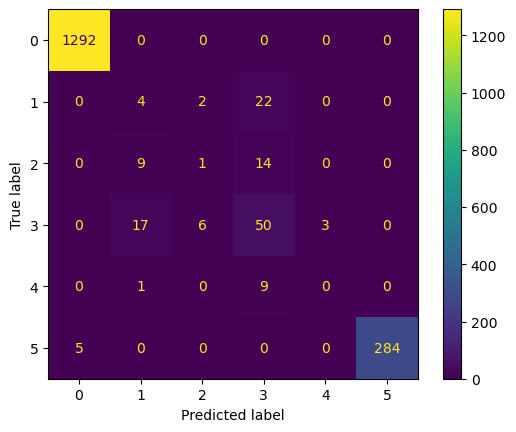

In [51]:
cm_test_rf= confusion_matrix(y_test, y_pred_randfor)
ConfusionMatrixDisplay(cm_test_rf).plot()

Based on the confusion matrix, 5 data that was supposed to be charged off (worse than default) is predicted to be paid off, which is more than the previous model. This alone proves why we will not be using this model.

As usual, we store the result

In [52]:
total_misclassified = (cm_test_rf.sum() - np.trace(cm_test_rf))/len(y_test)

eval_randfor = {
    'Metric': ['Total Misclassified','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [total_misclassified, mae, kappa]
}

#### 3. Decision Tree

According to the Wikipedia, decision tree is a flowchart-like structure in which each internal node represents a test on an attribute (e.g. whether a coin flip comes up heads or tails), each branch represents the outcome of the test, and each leaf node represents a class label (decision taken after computing all attributes).

In [53]:
pipe_dt.fit(X_train, y_train)
y_pred_dt= pipe_dt.predict(X_test)

Let's take a look at the classification report result

In [54]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.17      0.21      0.19        28
           2       0.07      0.04      0.05        24
           3       0.48      0.50      0.49        76
           4       0.11      0.10      0.11        10
           5       1.00      0.98      0.99       289

    accuracy                           0.94      1719
   macro avg       0.47      0.47      0.47      1719
weighted avg       0.94      0.94      0.94      1719



Decision Tree is a less overfitting version of random forest. Hence, it's a preferable algorithm to reduce the overfitting tendency in RF algorithm.

Now we will see the MAE and Kappa score

In [55]:
mae = mean_absolute_error(y_test, y_pred_dt)
kappa = cohen_kappa_score(y_test, y_pred_dt, weights='quadratic')
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0995
Cohen's Kappa (quadratic): 0.9678


Error score wise, it's less than RF. However, we need to visualize its prediction using confusion matrix to see the correctness:

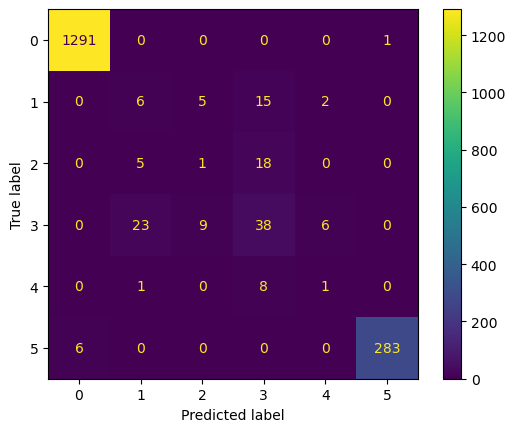

In [56]:
cm_test_dt= confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_test_dt).plot()

This model doesn't outperform the previous two because it predicts 6 people who are charged off as paid off. This model should not be pushed to production.

Now we store the results

In [57]:
total_misclassified = (cm_test_dt.sum() - np.trace(cm_test_dt))/len(y_test)

eval_dt = {
    'Metric': ['Total Misclassified','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [total_misclassified, mae, kappa]
}

#### 4. XGBoost

XGBoost corrects the previous mistake a Decision Tree make and use it to predict the next one. Just like random forest, it has a tendency to overfit

In [58]:
pipe_xgb.fit(X_train, y_train)
y_pred_xgb= pipe_xgb.predict(X_test)

Let's print out the classification report

In [59]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.19      0.21      0.20        28
           2       0.00      0.00      0.00        24
           3       0.54      0.66      0.60        76
           4       0.00      0.00      0.00        10
           5       0.99      0.99      0.99       289

    accuracy                           0.95      1719
   macro avg       0.45      0.48      0.46      1719
weighted avg       0.94      0.95      0.95      1719



As predicted, XGB overfits the data which causes the model not being able to predict default data.

Now let's see the score

In [60]:
mae = mean_absolute_error(y_test, y_pred_xgb)
kappa = cohen_kappa_score(y_test, y_pred_xgb, weights='quadratic')
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0826
Cohen's Kappa (quadratic): 0.9762


Score-wise, it performs great but as mentioned before, we want to see the real ability to predict correctly and safely.

Now let's take a look at the confusion matrix

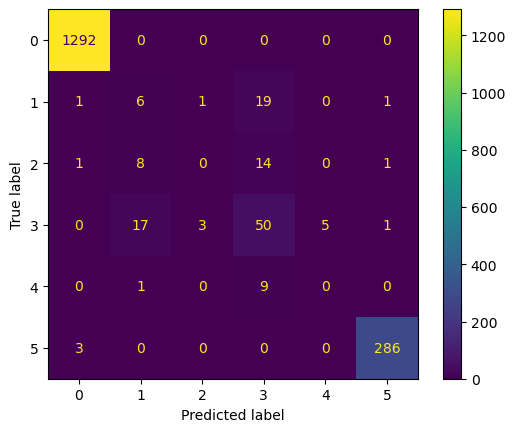

In [61]:
cm_test_xgb= confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_test_xgb).plot()

The model misclassifies 3 charged off credits with paid off, and 1 default with simply in a grace period. This will not be good for production.

Now we store the result

In [62]:
total_misclassified = (cm_test_xgb.sum() - np.trace(cm_test_xgb))/len(y_test)

eval_xgb = {
    'Metric': ['Total Misclassified','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [total_misclassified, mae, kappa]
}

#### 4. Support Vector Classifier
SVC thinks about the problem geometrically. It tries to find the best boundary line (or hyperplane in higher dimensions) that separates your classes with the maximum gap possible between them.

In [63]:
pipe_svc.fit(X_train, y_train)
y_pred_svc= pipe_svc.predict(X_test)

Let's see the classification report of SVC:

In [64]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1292
           1       0.22      0.36      0.27        28
           2       0.17      0.17      0.17        24
           3       0.52      0.43      0.47        76
           4       0.00      0.00      0.00        10
           5       0.98      0.96      0.97       289

    accuracy                           0.94      1719
   macro avg       0.48      0.49      0.48      1719
weighted avg       0.94      0.94      0.94      1719



Just like Random Forest, this model is not able to predict defaults

Let's see the MAE and Kappa

In [65]:
mae = mean_absolute_error(y_test, y_pred_svc)
kappa = cohen_kappa_score(y_test, y_pred_svc, weights='quadratic')
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.1117
Cohen's Kappa (quadratic): 0.9631


Score-wise, it is also the worst model

Let's visualize the SVC prediction:

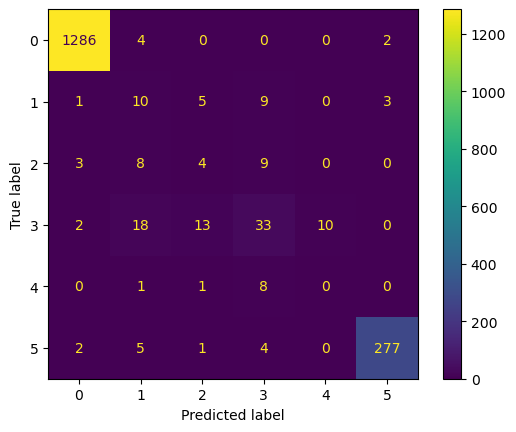

In [66]:
cm_test_svc= confusion_matrix(y_test, y_pred_svc)
ConfusionMatrixDisplay(cm_test_svc).plot()

The model also predicts many default and charged off credits with little accuracy. This signifies that this model is the worst

Let's store the overall score

In [67]:
total_misclassified = (cm_test_svc.sum() - np.trace(cm_test_svc))/len(y_test)

eval_svc = {
    'Metric': ['Total Misclassified','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [total_misclassified, mae, kappa]
}

### Model Review

Now we create a dataframe that store all the metrics of all the models we have tested

In [68]:
evaluation=pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost', 'SVC'],
    'Total Misclassified': [eval_logreg['Score'][0]*100, eval_randfor['Score'][0]*100, eval_dt['Score'][0]*100, eval_xgb['Score'][0]*100, eval_svc['Score'][0]*100],
    'Mean Absolute Error': [eval_logreg['Score'][1]*100, eval_randfor['Score'][1]*100, eval_dt['Score'][1]*100, eval_xgb['Score'][1]*100, eval_svc['Score'][1]*100],
    "Cohen's Kappa (quadratic)": [eval_logreg['Score'][2]*100, eval_randfor['Score'][2]*100, eval_dt['Score'][2]*100, eval_xgb['Score'][2]*100, eval_svc['Score'][2]*100]
})

evaluation.set_index('Model', inplace=True)

Let's view the score (note: all the numbers are in percentage)

In [69]:
evaluation

,Total Misclassified,Mean Absolute Error,Cohen's Kappa (quadratic)
Model,,,
Logistic Regression,6.515416,9.714951,97.582971
Random Forest,5.119255,8.667830,97.354449
Decision Tree,5.759162,9.947644,96.781582
XGBoost,4.944735,8.260617,97.615843
SVC,6.340896,11.169284,96.305436


Despite Logistic Regression not having as good score as the other algorithm, it will be chosen as the best model. The reason is because it's less overfitting and therefore will have less tendency to be biased.

Let's visualize the differences:

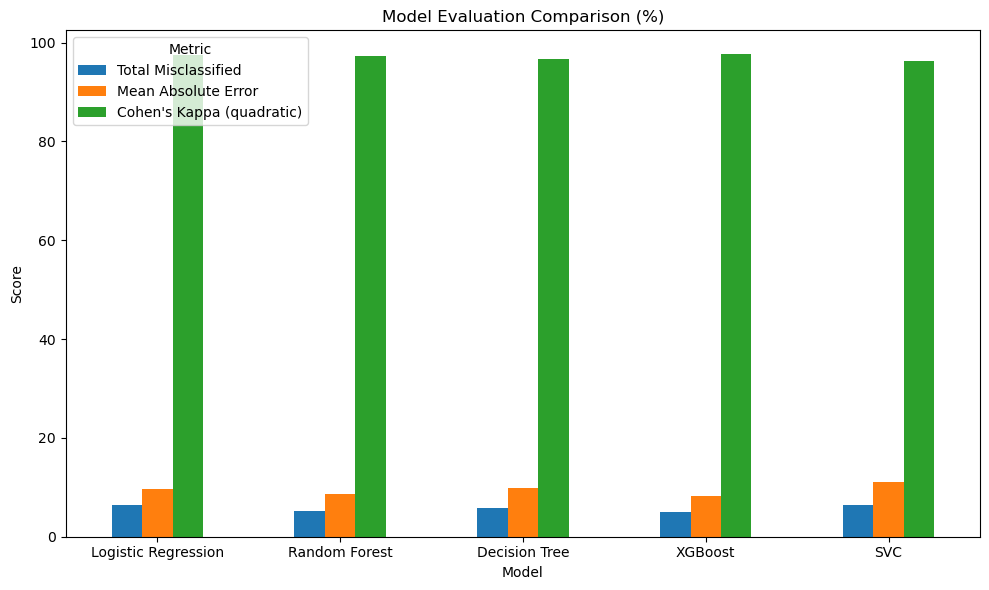

In [70]:
evaluation.plot(kind='bar', figsize=(10, 6), edgecolor='none')
plt.title('Model Evaluation Comparison (%)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

As we can see, the differences is minimal between model which means that we can fine tune the logistic regression into something better

### Fine Tune Model
In order to get a better score, we will fine tune the model of logistic regression

Let's take a look at the parameter keys first:

In [71]:
pipe_logreg.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'smote', 'df_converter', 'classifier', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num_scaler', 'preprocessor__num_minmax', 'preprocessor__cat_onehot', 'preprocessor__cat_grade', 'preprocessor__cat_verification', 'preprocessor__num_scaler__memory', 'preprocessor__num_scaler__steps', 'preprocessor__num_scaler__transform_input', 'preprocessor__num_scaler__verbose', 'preprocessor__num_scaler__scaler', 'preprocessor__num_scaler__scaler__copy', 'preprocessor__num_scaler__scaler__with_mean', 'preprocessor__num_scaler__scaler__with_std', 'preprocessor__num_minmax__memory', 'preprocessor__num_minmax__steps', 'preprocessor__num_minmax__transform_input', 'preprocessor__num_minmax__verbose', '

Then we use grid seach to find the best parameters:

In [72]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10], # Regularization strength
    'classifier__penalty': ['l1', 'l2'], # Regularization type
    'classifier__solver': ['liblinear', 'saga'], # Solvers that support both l1 and l2 penalties
    'classifier__max_iter': [100, 200, 500] # Maximum iterations for convergence
}

grid_search = GridSearchCV(pipe_logreg, param_grid, cv=5, n_jobs=-1, verbose=2) 
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters found:  {'classifier__C': 10, 'classifier__max_iter': 500, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}


Using the best grid search parameter, we will test it:

In [73]:
y_pred_logreg_tuned = grid_search.predict(X_test)

Now let's print out the classification report:

In [74]:
print(classification_report(y_test, y_pred_logreg_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.18      0.18      0.18        28
           2       0.24      0.33      0.28        24
           3       0.52      0.22      0.31        76
           4       0.12      0.50      0.20        10
           5       1.00      1.00      1.00       289

    accuracy                           0.94      1719
   macro avg       0.51      0.54      0.49      1719
weighted avg       0.95      0.94      0.94      1719



Numbers-wise, it performs better than the previous logreg model

Time to see the MAE and Kappa score:

In [75]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_logreg_tuned)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_logreg_tuned, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0861
Cohen's Kappa (quadratic): 0.9798


It has less error and better agreement to the test also

Now we visualize the confusion matrix:

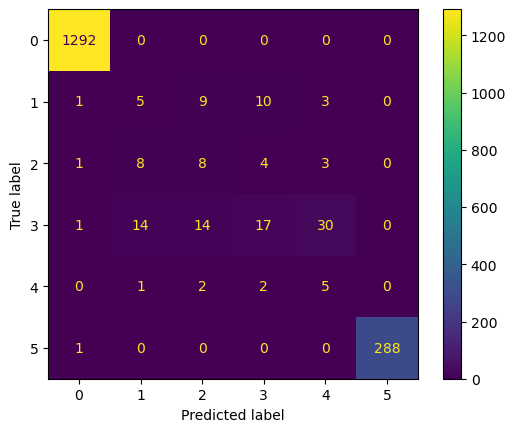

In [76]:
cm_test_tuned= confusion_matrix(y_test, y_pred_logreg_tuned)
ConfusionMatrixDisplay(cm_test_tuned).plot()

The prediction is also better overall

Now we store the score metrics

In [77]:
total_misclassified = (cm_test_tuned.sum() - np.trace(cm_test_tuned))/len(y_test)

eval_tuned_logreg = {
    'Metric': ['Total Misclassified', 'Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [total_misclassified, mae, kappa]
}

In [78]:
evaluation=pd.concat([evaluation, pd.DataFrame({
    'Model': ['Tuned :Logistic Regression'],
    'Total Misclassified': [eval_tuned_logreg['Score'][0]*100],
    'Mean Absolute Error': [eval_tuned_logreg['Score'][1]*100],
    "Cohen's Kappa (quadratic)": [eval_tuned_logreg['Score'][2]*100]
}).set_index('Model')])

Let's visualize the comparison score to the other model previously:

Text(0.5, 1.0, 'Model Evaluation Comparison (%)')

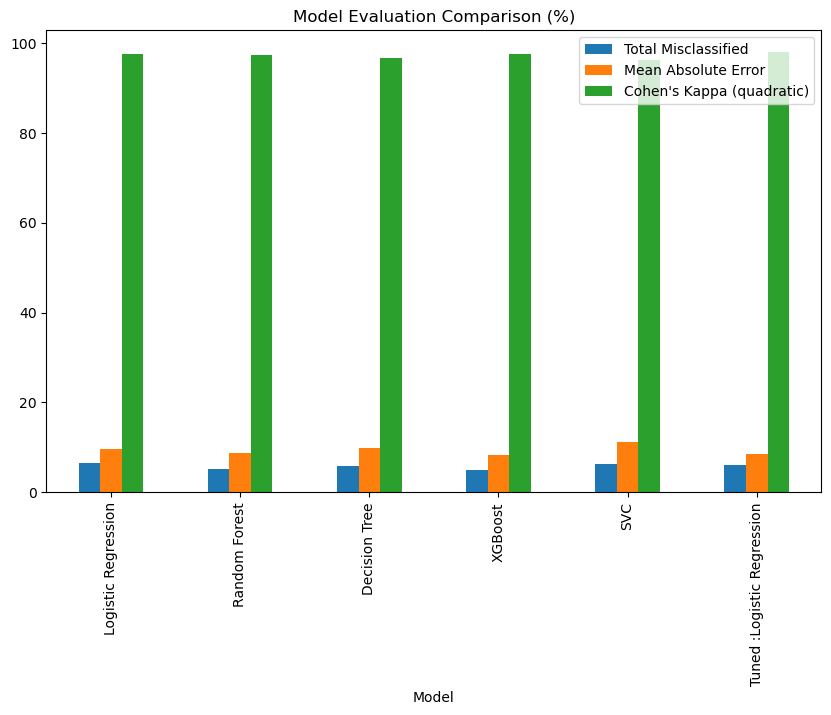

In [79]:
evaluation.plot(kind='bar', figsize=(10, 6), edgecolor='none')
plt.title('Model Evaluation Comparison (%)')

And now let's take a look at the number:

In [80]:
evaluation

,Total Misclassified,Mean Absolute Error,Cohen's Kappa (quadratic)
Model,,,
Logistic Regression,6.515416,9.714951,97.582971
Random Forest,5.119255,8.667830,97.354449
Decision Tree,5.759162,9.947644,96.781582
XGBoost,4.944735,8.260617,97.615843
SVC,6.340896,11.169284,96.305436
Tuned :Logistic Regression,6.050029,8.609657,97.978951


Based on the numbers, we have reduced the number of miscalssified data by 0.5% and the error by 1%, while increasing the kappa agreement score by 0.39%. This seems to be a good improvement because we have solved the low score of the logistic regression without it being overfitting like the other model.

Now we save the model:

In [81]:
model_best = grid_search.best_estimator_
joblib.dump(model_best, open('model_best.pkl', 'wb'))

And visualize what the pipeline looks like:

In [82]:
model_best

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaler', ...), ('num_minmax', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready 

In [84]:
import sklearn
import imblearn
import xgboost

print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)
print("xgboost:", xgboost.__version__)

# Also check the exact error line
import inspect
from sklearn.linear_model import LogisticRegression
print(inspect.getfile(LogisticRegression))

sklearn: 1.8.0
imblearn: 0.14.1
xgboost: 3.2.0
c:\Users\daru1\miniconda3\envs\latest\Lib\site-packages\sklearn\linear_model\_logistic.py


In [85]:
test_input = X_test.iloc[:1]
model_best.predict_proba(test_input)

array([[4.51521492e-13, 8.63040071e-02, 9.37876750e-02, 2.07417813e-01,
        6.12479698e-01, 1.08071420e-05]])